In [4]:

# Common imports
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as const
import numpy as np
import matplotlib as mpl

from matplotlib.transforms import Bbox
from scipy.linalg import eigh

## Constants and calibrational data

In [5]:
# ------------------ Physical constants ------------------
Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1
Delta_Al = 3.4e-4*e # J

# ------------------ System parameters ------------------
T = 15e-3 #K
Ec= 0.233e9*h #JAC
C = e**2/(2*Ec) #F

Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm^2


## Hamiltonian construction

In [6]:

def build_phase_hamiltonians(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        ng: float,
) -> np.ndarray:

    """
    Construct phase-basis Hamiltonians for a superconducting circuit.
    """
    # ----------------- Phase grid -----------------
    phis = phis * 2*np.pi
    N = len(phis)
    delta_phi = phis[1] - phis[0]

    # ----------------- Differential operators -----------------
        # First derivative
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Second derivative (Laplacian)
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ----------------- Kinetic term -----------------
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # ----------------- Effective left arm SQUID parameters -----------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    # Transmission coefficients (clipped for stability)
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)

    # ----------------- Capacitances & charging energies for internal modes -----------------

    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

    C_mod_R = CJ3 + CJ45
    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

    # ----------------- Energy scales -----------------
    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff

    # ----------------- Grid reshaping -----------------
    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    V = np.zeros((len(flux1), N, N), dtype=float)

    # ----------------- Potential energy prefactors -----------------
    PF_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    PF_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    PF_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2)
    PF_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2))

    # ----------------- Potential energy -----------------
    V_phi = -(E_L * PF_L + E_R * PF_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])  

    # ----------------- Full Hamiltonian -----------------
    H_all = V + T[None, :, :] 

    return H_all, V_phi, phis


In [7]:
a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

## Spectrum computation

In [8]:
def compute_spectrum(flux1_val, flux2_val):
    H_all, V_psi, phis = build_phase_hamiltonians(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        phis=phi,
        flux1=np.array([flux1_val]),
        flux2=flux2_val,
        Ec=Ec, ng=ng,
    )

    H = H_all[0]
    H = (H + H.conj().T) / 2
    evals, evecs = np.linalg.eigh(H)
    evals = np.real(evals)

    phis = phis / (2*np.pi)
    E0 = evals[0]
    evals -= E0
    V = V_psi[0, :] - E0

    return phis, evals, evecs, V


## Potential computation and vizualization

In [9]:
def plot_phase_basis_stack(
    ax,
    flux1_val,
    flux2_val,
    potential_color,
    marker,
    dashed_levels=None,
):
    if dashed_levels is None:
        dashed_levels = []

    H_all, V_psi, phis = build_phase_hamiltonians(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        phis=phi,
        flux1=np.array([flux1_val]),
        flux2=flux2_val,
        Ec=Ec, ng=ng,
    )

    H = H_all[0]
    H = (H + H.conj().T) / 2
    evals, evecs = np.linalg.eigh(H)
    evals = np.real(evals)

    phis = phis / (2*np.pi)
    E0 = evals[0]
    evals -= E0

    psi_scale = 8.0 * np.abs(evals).max() / dim 

    # Potential
    ax.plot(
        phis,
        V_psi[0, :] - E0,
        color=potential_color,
        lw=0.8,
        ls="--",
        label=r"$U(\varphi)$"
    )

    # Wavefunctions with parity coloring
    for i in range(4):

        psi = (evecs[:, i])
        linestyle = "-." if i in dashed_levels else "-"

        if i % 2 == 0:  # even parity
            color = even_colors[i]
        else:           # odd parity
            color = odd_colors[i]

        ax.plot(
            phis,
            evals[i] - psi * psi_scale,
            lw=0.8,
            ls=linestyle,
            color=color,
            label=rf"$|\psi_{i}|^2$"
        )

    ax.scatter(
        0.125, 0.94,
        transform=ax.transAxes,
        s=15,
        color=potential_color,
        marker=marker,
        linewidths=0.2,
        zorder=15,
        clip_on=False,
    )

    ax.set_xlabel(r"Phase $\varphi / 2\pi$")


## System parameters

In [10]:

# ------------------------------------------
Ec = 0.210
EJ1 = 70
EJ2 = 70
EJ3  = 70
EJ4  = 40
EJ5  = 40
ng = 0

phi = np.linspace(-0.5, 0.5, 51)

ncut = 50
dim = 2 * ncut + 1


# Flux grids
flux1_vals = np.linspace(0, 1, 101)  # Flux1
flux2_vals = np.linspace(0, 0.5, 101)  # Flux2

## Main computation

In [11]:

f01_2d = np.zeros((len(flux1_vals), len(flux2_vals)))

# Compute f01 across grid
for i, flux1 in enumerate(flux1_vals):
    for j, flux2 in enumerate(flux2_vals):
        # Build Hamiltonian for this flux point
        H_all, D1, _ = build_phase_hamiltonians(
            EJ1, EJ2, EJ3, EJ4, EJ5,
            np.array([flux1]), flux2, phi,  Ec, ng
        )

        H = H_all[0]

        # Compute eigenvalues
        eigvals, _ = eigh(H)

        # Sort and take first two levels
        eigvals = np.real(eigvals)
        E0, E1 = eigvals[0], eigvals[1]

        # Compute transition frequency f01
        f01_2d[i, j] = (E1 - E0)

# ------------------------------------------

flux1_A = 0.5
flux2_A = 0.48

flux1_B =  0.5
flux2_B =  0.1605

## Visualization

In [12]:
# ------------------ Plot styling ------------------
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})

even_cmap = mpl.colormaps["Oranges"]
odd_cmap  = mpl.colormaps["Purples"]

even_colors = {
    0: even_cmap(0.65),
    2: even_cmap(0.85),
}

odd_colors = {
    1: odd_cmap(0.65),
    3: odd_cmap(0.9),
}

c_Transmon = "#9c334d"
c_cos2phi = "#598D07"

c:\Users\nzhurbina\AppData\Local\anaconda3\envs\gatemon\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\nzhurbina\AppData\Local\anaconda3\envs\gatemon\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


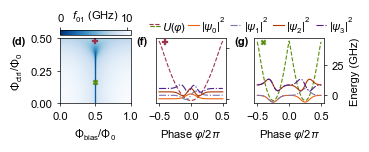

In [14]:

fig = plt.figure()
fig.set_size_inches(3.40457, 0.85)

# ============================================================
# Adjustable widths
# ============================================================
MAP_WIDTH   = 1    # width of the 2D map
GAP1        = 0.08   # gap between map and colorbar
CBAR_WIDTH  = 0.08   # width of colorbar
GAP2        = 0.2# gap between colorbar & Pot A
POT_A_WIDTH = 1.0    # width of Potential A
GAP3        = 0.4  # gap between Pot A & Pot B
POT_B_WIDTH = 1.0    # width of Potential B
# ============================================================

# FULL 1×7 GRID:
# [ MAP | GAP1 | CBAR | GAP2 | POTA | GAP3 | POTB ]
outer = fig.add_gridspec(
    1, 7,
    width_ratios=[
        MAP_WIDTH,
        GAP1,
        CBAR_WIDTH,
        GAP2,
        POT_A_WIDTH,
        GAP3,
        POT_B_WIDTH
    ],
    wspace=0  # we use NO internal spacing
)

# Assign axes
ax_map  = fig.add_subplot(outer[0, 0])
ax_potA = fig.add_subplot(outer[0, 4])
ax_potB = fig.add_subplot(outer[0, 6])

# GAP columns (1, 3, 5) are empty on purpose.

ax_map.scatter(flux1_A, flux2_A, marker="P", s=15, c=c_Transmon, linewidths=0.2)
ax_map.scatter(flux1_B, flux2_B, marker="X", s=15, c=c_cos2phi, linewidths=0.2)
# -----------------------
# Example map plot
# -----------------------
im = ax_map.imshow(
    f01_2d.T,
    origin="lower",
    extent=[flux1_vals.min(), flux1_vals.max(),
            flux2_vals.min(), flux2_vals.max()],
    aspect="auto",
    cmap="Blues_r"
)


ax_map.set_xlabel("$\Phi_{\mathrm{ bias}}/\Phi_0$")
ax_map.set_ylabel("$\Phi_{\mathrm{ ctrl}}/\Phi_0$")

pos = ax_map.get_position()

# Add a new axes above ax_map for the colorbar (in figure coords)
cbar_height = 0.06  # height of colorbar in figure fraction
cbar_pad = 0.03     # gap between ax_map and colorbar

cax_top = fig.add_axes([
    pos.x0,                  # same x-position as ax_map
    pos.y1 + cbar_pad,       # just above ax_map
    pos.width,               # same width as ax_map
    cbar_height              # height of the colorbar
])

# Create horizontal colorbar
cbar = fig.colorbar(im, cax=cax_top, orientation="horizontal")
cbar.set_ticks([0, 10])
cbar.set_ticklabels(["0", "10"])

# Move label precisely
cbar.set_label(r"$f_{01}$ (GHz)", labelpad=2)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_coords(0.5, 3.2)  # center above bar
# Example potentials
# -----------------------
_, _, _, V_A = compute_spectrum(flux1_A, flux2_A)
_, _, _, V_B = compute_spectrum(flux1_B, flux2_B)

ymin = min(np.min(V_A), np.min(V_B))
ymax = min(np.max(V_A), np.max(V_B))

pad = 0.05 * (ymax - ymin)
ylim = (ymin - pad, ymax + pad)

plot_phase_basis_stack(ax_potA, flux1_val=flux1_A, flux2_val=flux2_A, potential_color=c_Transmon, marker = "P", dashed_levels=[1, 3])
ax_potA.tick_params(axis="y", labelleft=False)
ax_potA.yaxis.tick_right()
# ax_potA.yaxis.set_label_position("right")
ax_potA.set_ylabel("") 


plot_phase_basis_stack(ax_potB, flux1_val=flux1_B, flux2_val=flux2_B, potential_color=c_cos2phi, marker = "X", dashed_levels=[1, 3])

ax_potB.set_ylim(ylim)
ax_potB.yaxis.tick_right()
ax_potB.yaxis.set_label_position("right")
ax_potB.set_ylabel("Energy (GHz)")


handles, labels = ax_potA.get_legend_handles_labels()

# Union of Pot A and Pot B positions (in figure coords)
bbox = Bbox.union([
    ax_potA.get_position(),
    ax_potB.get_position()
])


fig.legend(
    handles[1:],
    labels[1:],
    loc="upper center",
    bbox_to_anchor=(bbox.x0 + bbox.width / 2+0.09, bbox.y1 + 0.4),
    bbox_transform=fig.transFigure,
    ncol=len(handles),   # single horizontal row
    frameon=False,
    handlelength=1,
    columnspacing=0.4,
    handletextpad=0.2,
)
import matplotlib.transforms as mtransforms

leg = fig.legend(
    handles[:1],
    labels[:1],
    loc="upper center",
    bbox_to_anchor=(bbox.x0 +0.035, bbox.y1 + 0.36),
    bbox_transform=fig.transFigure,
    ncol=len(handles),   # single horizontal row
    frameon=False,
    handlelength=1,
    columnspacing=0.4,
    handletextpad=0.2,
)
offset = mtransforms.ScaledTranslation(0, 3/125, fig.dpi_scale_trans)

for text in leg.get_texts():
    text.set_transform(text.get_transform() - offset)

handles_B, labels_B = ax_potB.get_legend_handles_labels()

leg_top = ax_potB.legend(
    handles_B[:1],
    [''],                  # empty label
    loc="upper center",
    bbox_to_anchor=(-1.41, bbox.y1 + 0.52),
    frameon=False,
    handlelength=1,
    handletextpad=0        # remove space where text would be
)

ax_potB.add_artist(leg_top)


# Labeling
for ax, label in zip([ax_map], ["(d)"]):
    ax.text(-0.7, 0.9, label, transform=ax.transAxes, fontweight="bold")

for ax, label in zip([ax_potA, ax_potB], ["(f)", "(g)"]):
    ax.text(-0.28, 0.9, label, transform=ax.transAxes, fontweight="bold")


# for ax, label in zip([ax_map, ax_potA, ax_potB], ["(a)", "(b)", "(c)"]):
#     ax.text(-0.28, 2, label, transform=ax.transAxes, fontweight="bold")

# fig.savefig("resonator_pot.svg", format="svg", bbox_inches="tight")
fig.savefig("Fig1_Potential.pdf", format="pdf", bbox_inches="tight")
plt.show()
